In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns

In [6]:
import warnings
warnings.filterwarnings("ignore")
sns.set(style="whitegrid")

In [7]:
df = pd.read_csv("AIML Dataset.csv")


In [8]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [ ]:
df = pd.read_csv("AIML Dataset.csv")

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [ ]:
df.columns

In [ ]:
df["isFraud"].value_counts()

In [ ]:
df["isFlaggerFraud"].value_counts()

In [ ]:
df.isnull().sum().sum()

In [ ]:
df.shape[0]

In [ ]:
(df(["isFraud"].value_counts()[1]/df.shape[0]) * 100, 2)

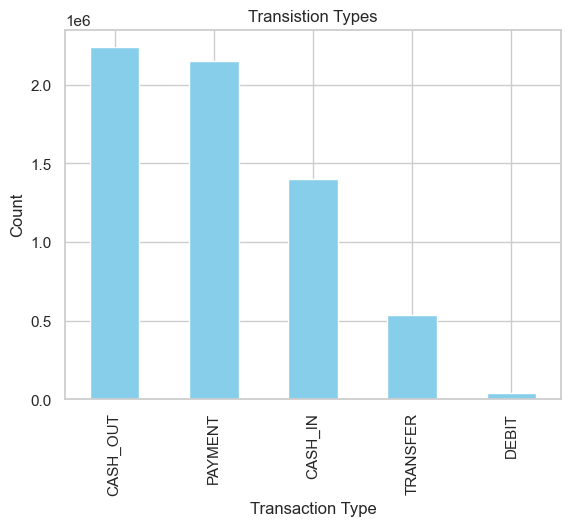

In [10]:
df["type"].value_counts().plot(kind="bar" , title ="Transistion Types",color = "skyblue")
plt.xlabel("Transaction Type")
plt.ylabel("Count")
plt.show()

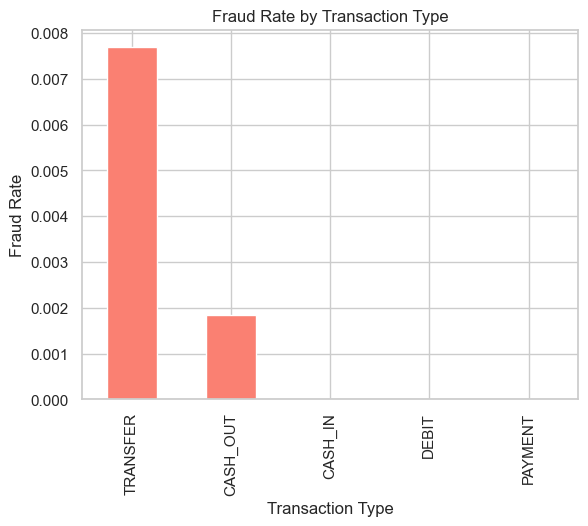

In [13]:
fraud_by_type = df.groupby("type")["isFraud"].mean().sort_values(ascending=False)
fraud_by_type.plot(kind="bar", title="Fraud Rate by Transaction Type", color="salmon")
plt.ylabel("Fraud Rate")
plt.xlabel("Transaction Type")
plt.show()

In [ ]:
df["amount"].describe().astype(int)



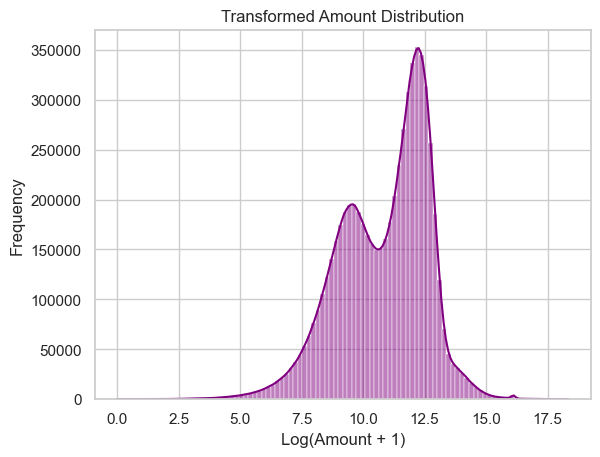

In [15]:
sns.histplot(np.log1p(df["amount"]), kde=True, bins=100, color="purple")
plt.title("Transformed Amount Distribution")
plt.xlabel("Log(Amount + 1)")
plt.ylabel("Frequency")
plt.show()

In [ ]:
sns.boxplot(data= df[df["amount"]<50000],x="isFraud",y="amount")
plt.title("Amount vs Fraud (Filtered under 50k)")
plt.show()

In [ ]:
df["balanceDiffOrig"] = df["oldBalanceOrg"] - df["newBalanceOrg"]
df["balanceDiffDest"] = df["newBalanceDest"] - df["oldBalanceDest"]

In [ ]:
(df["balanceDiffDest"] < 0).sum()

In [ ]:
(df["balanceDiffOrig"] < 0).sum()

In [ ]:
df.head(2)

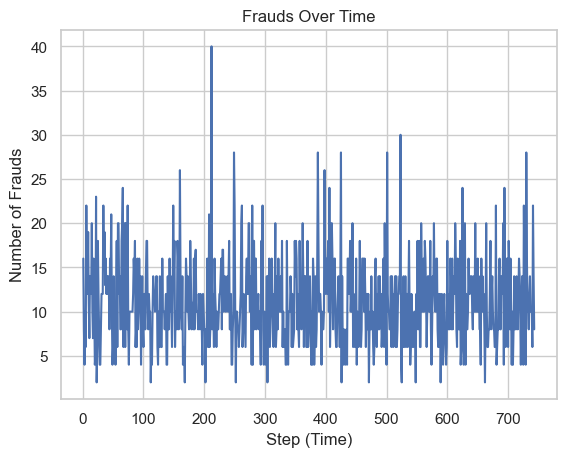

In [18]:
fraud_per_step = df[df["isFraud"] == 1]["step"].value_counts().sort_index()
plt.plot(fraud_per_step.index, fraud_per_step.values, label=["Frauds per Step"])
plt.xlabel("Step (Time)")
plt.ylabel("Number of Frauds")
plt.title("Frauds Over Time")
plt.grid(True)
plt.show()

In [ ]:
df.drop(column="step", inplace=True)

In [ ]:
df.head()

In [ ]:
top_sender = df["nameOrig"].value_counts().head(10)

In [ ]:
top_receiver = df["nameDest"].value_counts().head(10)

In [ ]:
top_receivers

In [ ]:
fraud_users = df[df["isFraud"] == 1]["nameOrig"].value_counts().head(10)

In [ ]:
fraud_users

In [ ]:
fraud_type = df[df["type"].isin(["TRANSFER"])]


In [ ]:
fraud_types["type"].value_counts()

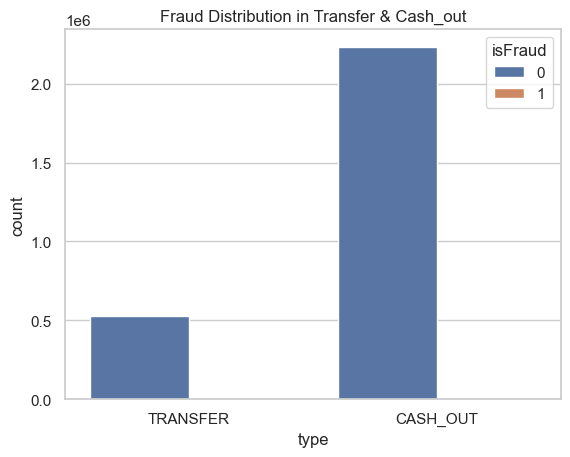

In [25]:
fraud_type = df[df["type"].isin(["TRANSFER", "CASH_OUT"])]
sns.countplot(data=fraud_type, x="type", hue='isFraud')
plt.title("Fraud Distribution in Transfer & Cash_out")
plt.show()

In [ ]:
corr =  df[['amount', 'oldbalance', 'newbalance',"newbalanceOrig","newbalanceDest","isFraud"]].corr()


In [ ]:
corr